# **Feature Engineering and Data Preparation**

In practical machine learning applications, raw datasets frequently require significant preprocessing prior to ingestion by algorithmic models. Data rarely arrives in a fully optimized state; therefore, practitioners must perform a series of data preparation steps to transform raw information into usable inputs.

**Data Preparation encompasses several critical stages:**

1.  **Data Cleaning**: This initial phase focuses on improving data quality. It involves identifying and addressing issues such as:
    *   **Missing Data**: Handling incomplete records through imputation (e.g., mean, median, mode), deletion, or more sophisticated techniques.
    *   **Outliers**: Detecting and managing anomalous data points that can distort statistical analyses and model training, often through capping, transformation, or removal.
    *   Other methods like Noise Reduction: Smoothing out random errors or inconsistencies in the data.

2.  **Feature Engineering**: This is formally defined as the application of domain knowledge to extract, create, or transform existing variables into mathematically viable features from raw data, utilizing data mining techniques. Its goal is to make the predictive power of learning algorithms more efficient by providing relevant and well-structured inputs.

    Machine learning algorithms fundamentally operate on numerical data. For instance, linear regression ($y = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$) requires all input features ($x$) to be numeric (floating-point numbers or integers), meaning text, categorical labels, and complex timestamps must be converted.

    To achieve the goals of feature engineering, data scientists generally employ three primary methodologies:

    *   **Extracting**: Deriving new features from existing ones (e.g., extracting day, month, year from a timestamp).
    *   **Combining**: Merging multiple features to create more informative ones (e.g., interaction terms).
    *   **Transforming**: Converting data into a suitable format for models (e.g., scaling numerical features, encoding categorical features).

<br><br>

## **Feature Engineering:**

- ### **Extracting Information**
  Extraction is the process of parsing complex data structures to isolate and utilize their fundamental numeric components.

  ##### **Timestamp Extraction**

  Raw timestamps (e.g., `1990-12-01 22:30:00`) cannot be processed directly by standard regression models. Instead, the constituent temporal components must be extracted to form independent numeric features:

  - Year: 1990
  - Month: 12
  - Mon:1, Tue:2, ..., Sun:7
  - Weekday or Weekend (0/1)

  Boolean Classifications: A binary indicator representing whether the date falls on a weekend (1) or a weekday (0).

- ### **Combining Information**

  Feature combination involves synthesizing two or more existing variables to expose deeper relationships within the data.

  **Interaction Terms:** Multiplying two continuous variables to capture their combined effect (e.g., `advertising_spend * radio_spend`).

  **Synthesizing Extracted Features:** Utilizing domain expertise to create higher-level features. For example, within a hospitality dataset, a binary Nightlife feature could be engineered to register as 1 strictly when an extracted timestamp indicates both an evening hour and a weekend date.

  The initial dataset contains only the transaction identifier and a raw timestamp.

  | Transaction_ID | Raw_Timestamp | Purchase_Amount |
  | :--- | :--- | :--- |
  | 001 | 2023-10-13 21:30:00 | $45.00 |
  | 002 | 2023-10-14 14:15:00 | $12.50 |
  | 003 | 2023-10-14 23:45:00 | $85.00 |
  | 004 | 2023-10-16 20:30:00 | $22.00 |

  Before synthesis can occur, the necessary independent variables must be extracted from the `Raw_Timestamp`.
  * **Day_of_Week:** Extracted to identify if the day is a Friday (5) or Saturday (6).
  * **Hour:** Extracted using a 24-hour clock to identify the time of day.

  | Transaction_ID | Day_of_Week | Hour | Purchase_Amount |
  | :--- | :--- | :--- | :--- |
  | 001 | Friday | 21 | $45.00 |
  | 002 | Saturday | 14 | $12.50 |
  | 003 | Saturday | 23 | $85.00 |
  | 004 | Monday | 20 | $22.00 |

  Now, domain knowledge is applied. The business defines "Nightlife" strictly as any transaction occurring on a Friday or Saturday, at or after 20:00 (8:00 PM).

  By combining the two extracted features using logical conditions, a single, highly predictive binary feature is synthesized.

  * **Logic:** IF (`Day_of_Week` is Friday OR Saturday) AND (`Hour` $\ge$ 20), THEN `Nightlife` = 1, ELSE `Nightlife` = 0.

  | Transaction_ID | Day_of_Week | Hour | **Nightlife (Synthesized)** | Rationale |
  | :--- | :--- | :--- | :--- | :--- |
  | 001 | Friday | 21 | **1** | Meets both conditions (Weekend AND $\ge$ 20:00). |
  | 002 | Saturday | 14 | **0** | Fails hour condition (14 < 20). |
  | 003 | Saturday | 23 | **1** | Meets both conditions (Weekend AND $\ge$ 20:00). |
  | 004 | Monday | 20 | **0** | Fails day condition (Monday is not a weekend). |

  By synthesizing this higher-level feature, the machine learning model is directly provided with the operational context (the "Nightlife" environment) without having to mathematically deduce the complex interaction between specific days and times on its own.

- ### **Transforming Information (Categorical Data)**

  Dataset variables frequently manifest as string-based categorical data.

  Transformation is required to convert these strings into algorithm-compatible numerical arrays.

  - ##### **A. Integer Encoding (Ordinal Data)**

    Integer encoding maps string categories directly to sequential integers (e.g., USA → 1, Mexico → 2, Canada → 3).

    While computationally efficient and conservative with dimensionality, this method inherently implies an **ordinal relationship**.

    The algorithm interprets the integer 3 as mathematically superior to 1, which is invalid for nominal categories like geographical regions.

    Integer encoding should be strictly reserved for categories possessing a natural hierarchy, such as a `Spice_Level` attribute:

    * Mild → 1
    * Hot → 2
    * Fire → 3



  - #####  **B. One-Hot Encoding (Nominal Data)**

    To process nominal variables without injecting false ordinality, one-hot encoding (or the creation of dummy variables) is utilized.

    This technique generates a discrete binary feature (0 or 1) for every unique category within the variable.



    While this eliminates assumed hierarchies, it significantly increases the dimensionality of the dataset and introduces a critical statistical vulnerability known as the Dummy Variable Trap.



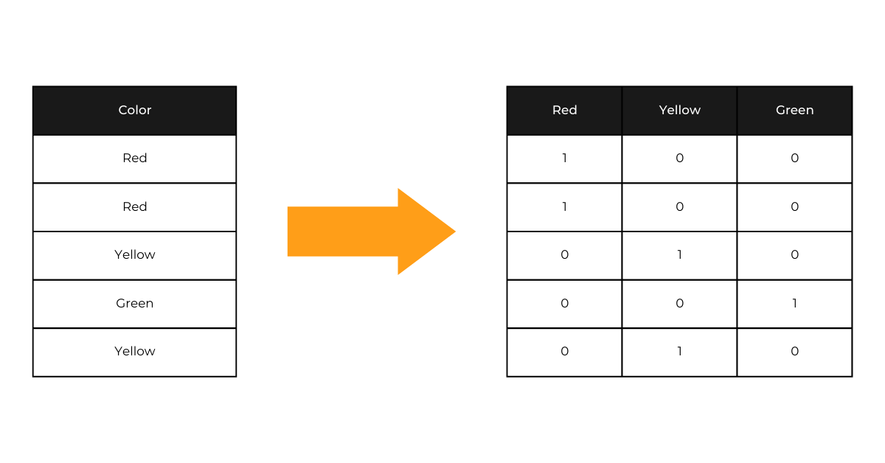

  - #####  **C. Multicollinearity and the Dummy Variable Trap**

    One-hot encoding intrinsically creates redundant information. If a binary variable tracks an orientation status of `Up` or `Down`, creating two separate dummy columns is mathematically redundant; if a system confirms `Up` (1), it is implicitly confirmed *not* to be `Down` (0).


    Passing perfectly collinear features into a regression model results in **multicollinearity**, which destabilizes coefficient estimation. The standard resolution is to systematically drop one column from the encoded set (e.g., representing three countries using only two dummy columns).

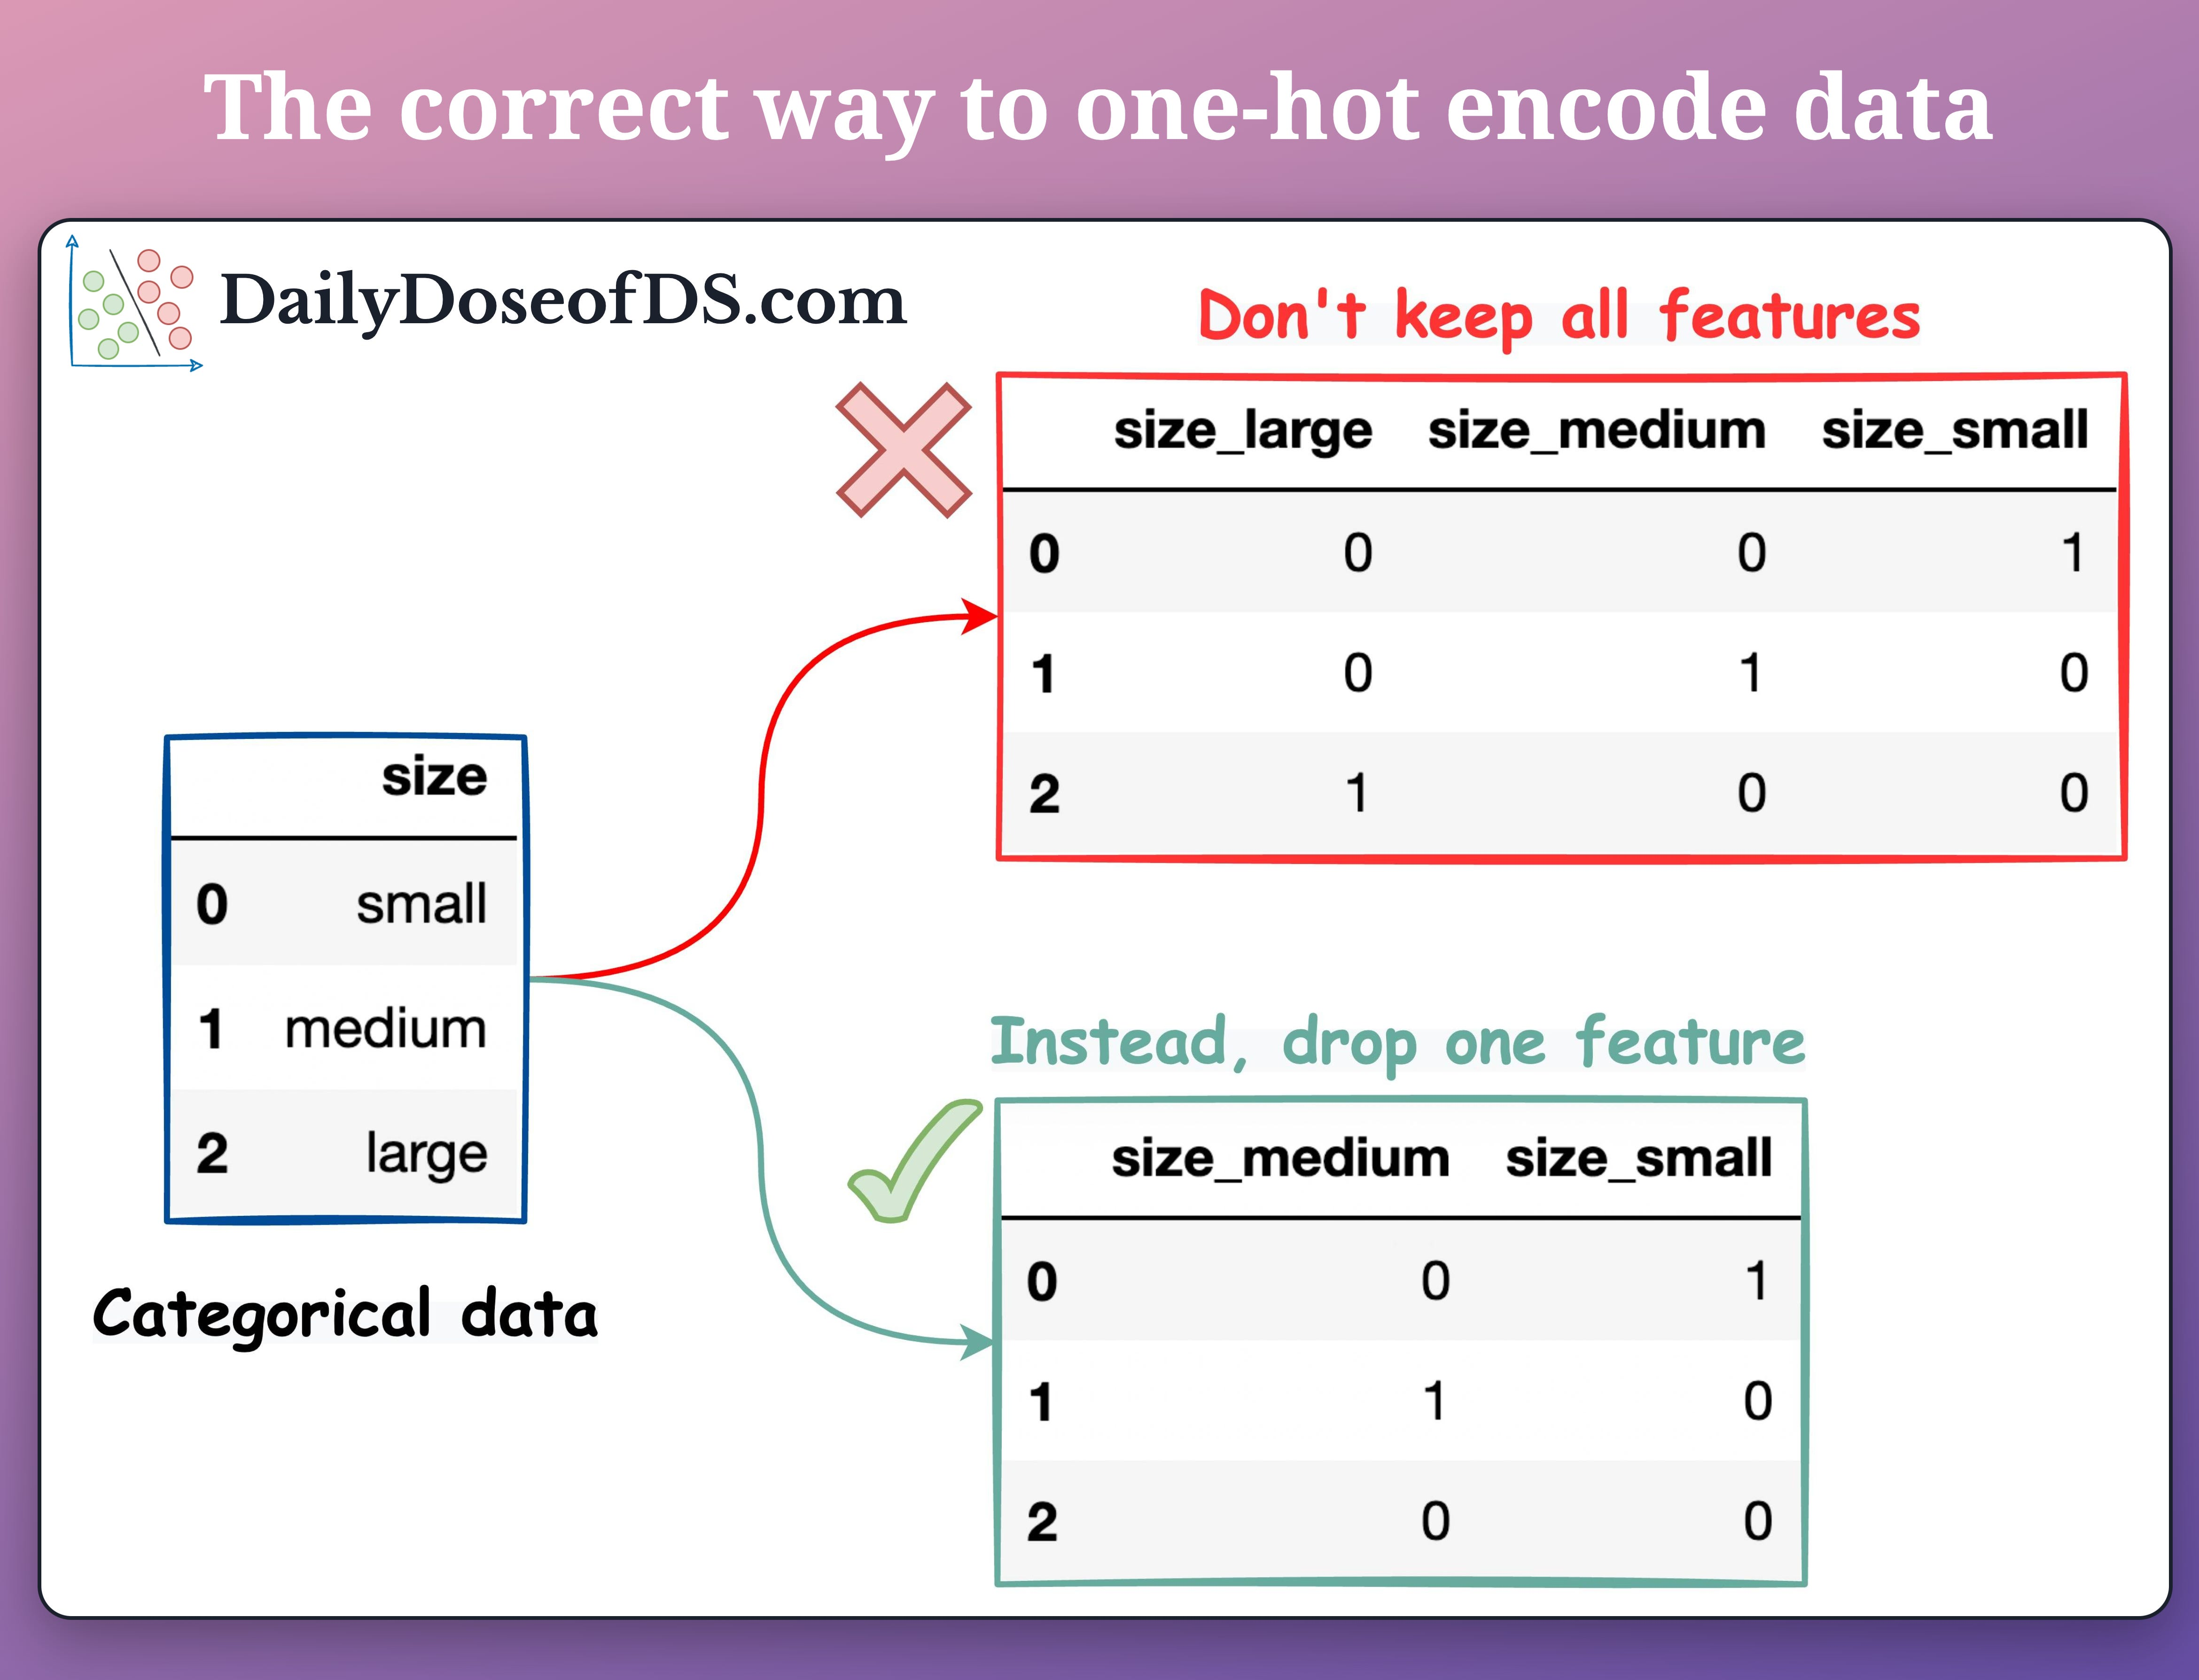

In [ ]:
# Import necessary analytical libraries
import pandas as pd
import numpy as np

# 1. Initialize raw dataset based on theoretical examples
data = {
    'timestamp': ['1990-12-01 22:30:00', '1990-12-04 10:15:00', '1990-12-08 23:00:00'],
    'spend': [45.50, 12.00, 60.00],
    'spice_level': ['Mild', 'Hot', 'Fire'],
    'country': ['USA', 'Mexico', 'Canada']
}

df = pd.DataFrame(data)
print("--- RAW DATA ---")
display(df)

# ==========================================
# PHASE 1: FEATURE EXTRACTION
# ==========================================
# Cast string representation to datetime objects
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract temporal subsets
df['Year'] = df['timestamp'].dt.year
df['Month'] = df['timestamp'].dt.month
df['Hour'] = df['timestamp'].dt.hour

# Isolate weekend occurrences (Monday=0, Sunday=6)
df['Day_of_Week'] = df['timestamp'].dt.dayofweek
df['Is_Weekend'] = df['Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

# ==========================================
# PHASE 2: FEATURE COMBINATION
# ==========================================
# Synthesize 'Nightlife' binary feature (Condition: Weekend AND Hour >= 20:00)
df['Nightlife'] = np.where((df['Is_Weekend'] == 1) & (df['Hour'] >= 20), 1, 0)

# ==========================================
# PHASE 3: FEATURE TRANSFORMATION
# ==========================================

# A. Integer Encoding (Applied to Ordinal Data)
spice_map = {'Mild': 1, 'Hot': 2, 'Fire': 3}
df['spice_level_encoded'] = df['spice_level'].map(spice_map)

# B. One-Hot Encoding (Applied to Nominal Data)
# Note: drop_first=True is utilized to circumvent the Dummy Variable Trap
df_dummies = pd.get_dummies(df['country'], prefix='country', drop_first=True, dtype=int)

# Concatenate dummy variables with the primary dataframe
df = pd.concat([df, df_dummies], axis=1)

# Purge original non-numeric columns post-transformation
df_final = df.drop(['timestamp', 'spice_level', 'country'], axis=1)

print("\n--- PROCESSED DATASET ---")
display(df_final)

--- RAW DATA ---


,timestamp,spend,spice_level,country
0,1990-12-01 22:30:00,45.5,Mild,USA
1,1990-12-04 10:15:00,12.0,Hot,Mexico
2,1990-12-08 23:00:00,60.0,Fire,Canada



--- PROCESSED DATASET ---


,spend,Year,Month,Hour,Day_of_Week,Is_Weekend,Nightlife,spice_level_encoded,country_Mexico,country_USA
0,45.5,1990,12,22,5,1,1,1,0,1
1,12.0,1990,12,10,1,0,0,2,1,0
2,60.0,1990,12,23,5,1,1,3,0,0


<br><br>

## **Data Cleaning:**

- ### **Missing Data**
  Missing data refers to the absence of values for certain observations or features. It's a common issue that can bias models and reduce their performance. Common techniques for handling missing data include:

  *   **Deletion**: Removing rows or columns with missing values (e.g., `df.dropna()`). This is straightforward but can lead to significant data loss if not used carefully.
  *   **Imputation**: Filling in missing values with estimated ones (e.g., mean, median, mode, or more advanced methods like K-Nearest Neighbors imputation or regression imputation). For a comprehensive guide on missing data imputation, refer to our previous Colab notebook on `Pandas_Missing_Data_New.ipynb`.

- ### **Outliers**
  Outliers are data points that significantly deviate from other observations. They can be due to measurement errors, data entry errors, or genuine but extreme variations. Outliers can adversely affect model training, leading to biased estimates and reduced model accuracy. Techniques for handling outliers include:

  *   **Identification**: Using statistical methods (e.g., Z-score, IQR method) or visualization (e.g., box plots, scatter plots, histograms).


  *   **Treatment**:
      *  **Do Nothing**
      *   **Removal**: Deleting outlier observations (similar to missing data deletion).
      *   **Transformation**: Applying mathematical transformations (e.g., log transformation, square root) to reduce the impact of extreme values.
      *   **Capping/Winsorization**: Replacing outliers with a specified percentile value (e.g., replacing values above the 99th percentile with the 99th percentile value).

- ### **Identification (How to find the outliers):**

  - #### **Visualization** (Initial Exploration):
    Visual methods are often the first step to identify potential outliers and understand their distribution context.
    *   **Box Plot**: Clearly shows the median, quartiles, and individual outliers beyond the whiskers.
    *   **Histogram**: Helps visualize the distribution of data and spot values far from the main peaks.
    *   **Scatter Plot**: Useful for identifying outliers in the context of multiple variables or over time.

  - #### **Statistical Methods**:
      - **IQR Rule (Interquartile Range)**
        The IQR rule is based on quartiles and is robust to extreme values.

        - Compute: $IQR = Q3 − Q1$
        - Define bounds: $\quad$ $x < Q1 − 1.5 \times IQR$   $\quad$ or  $\quad$    $x > Q3 + 1.5 \times IQR$
        - Any point outside these bounds is considered an **outlier**.
        
        This method works well for skewed or non-normal data.
      
      
      - **Z-Score Rule**

        The z-score measures how many standard deviations a value is from the mean.

        - Definition: z = (x − μ) / σ
        - Rule: |z| > 3 → often considered an outlier
        - Assumption: Data is approximately **normally distributed**.

  **Note:** Both methods are very domain-dependent! The choice of method and threshold should be guided by understanding the data and the problem.

  **Remember** that even if a data point is an outlier, it's still a data point! Carefully consider your data, its sources, and your goals whenever deciding to remove an outlier. Each case is different!

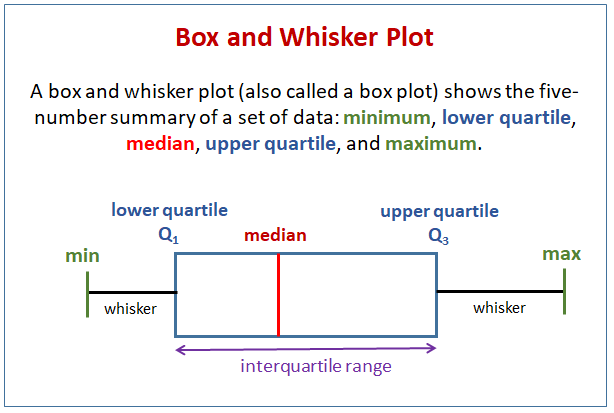

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a synthetic dataset with outliers based on 'Daily Sales Amount'
np.random.seed(42)

# Normal daily sales around $1000 with some variation
data_normal_sales = np.random.normal(loc=1000, scale=150, size=200)

# Introduce some exceptionally low sales (e.g., store closed for maintenance, holidays, or a glitch)
data_low_sales_outliers = np.random.normal(loc=150, scale=50, size=5)

# Introduce some exceptionally high sales (e.g., major promotional event, Black Friday)
data_high_sales_outliers = np.random.normal(loc=5000, scale=500, size=5)

# Combine all data
dataset_sales = np.concatenate([data_normal_sales, data_low_sales_outliers, data_high_sales_outliers])


In [ ]:
df = pd.DataFrame({'daily_sales_amount': dataset_sales})

print("Dataset Shape:", df.shape)

print("\n--- Synthetic Daily Sales Dataset ---\n")
display(df.describe())

Dataset Shape: (210, 1)

--- Synthetic Daily Sales Dataset ---



,daily_sales_amount
count,210.000000
mean,1080.191174
std,718.797334
min,81.116532
25%,888.210524
50%,999.371217
75%,1080.610814
max,6926.365745


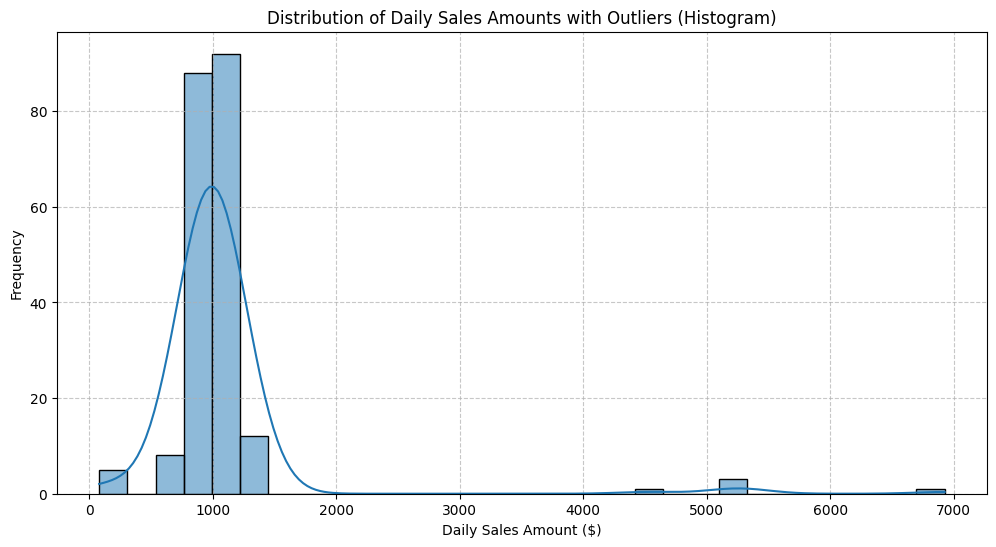

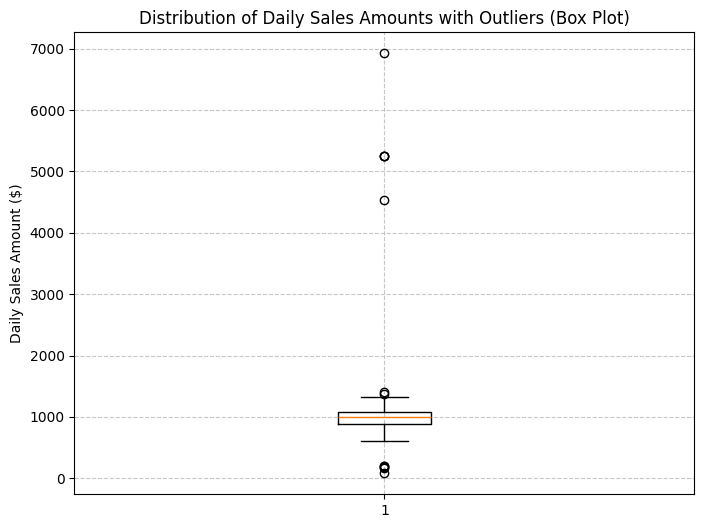

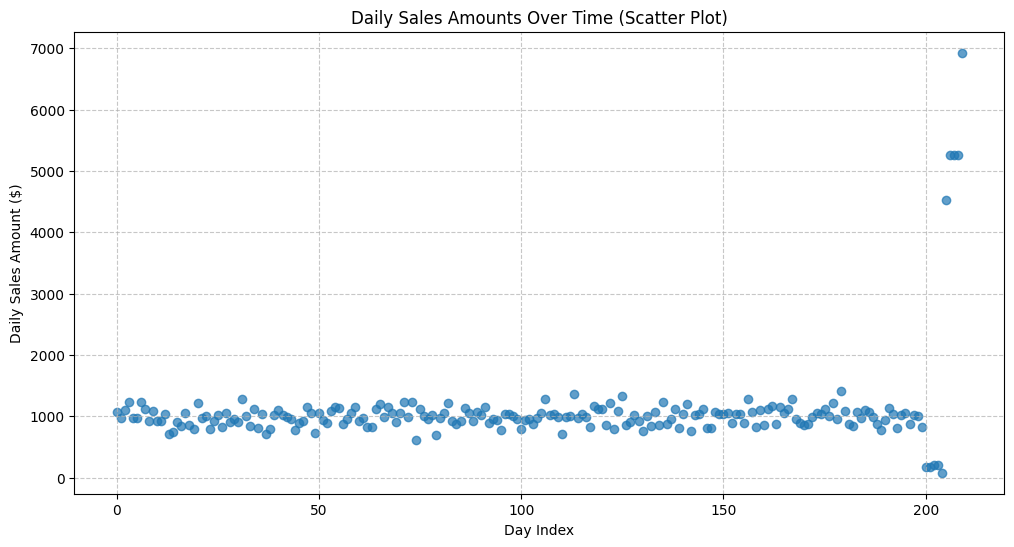

In [ ]:
# Visualize the distribution using a Histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_sales_amount'], kde=True, bins=30)
plt.title('Distribution of Daily Sales Amounts with Outliers (Histogram)')
plt.xlabel('Daily Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize the distribution using a Box Plot (inherently shows IQR outliers)
plt.figure(figsize=(8, 6))
plt.boxplot(df['daily_sales_amount'])
plt.title('Distribution of Daily Sales Amounts with Outliers (Box Plot)')
plt.ylabel('Daily Sales Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Visualize with a Scatter Plot (simple index vs. value to show individual points)
plt.figure(figsize=(12, 6))
plt.scatter(df.index, df['daily_sales_amount'], alpha=0.7)
plt.title('Daily Sales Amounts Over Time (Scatter Plot)')
plt.xlabel('Day Index')
plt.ylabel('Daily Sales Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Outlier Detection using Z-Score Method**

The Z-score measures how many standard deviations an data point is from the mean. A common threshold for identifying outliers is a Z-score greater than 2 or 3 (in absolute value), assuming the data is normally distributed.

--- Outliers detected by Z-Score (threshold > 2.5) ---



,daily_sales_amount,z_score
205,4531.087480,4.812403
206,5257.517634,5.825436
207,5256.892975,5.824565
208,5257.523843,5.825445
209,6926.365745,8.152707


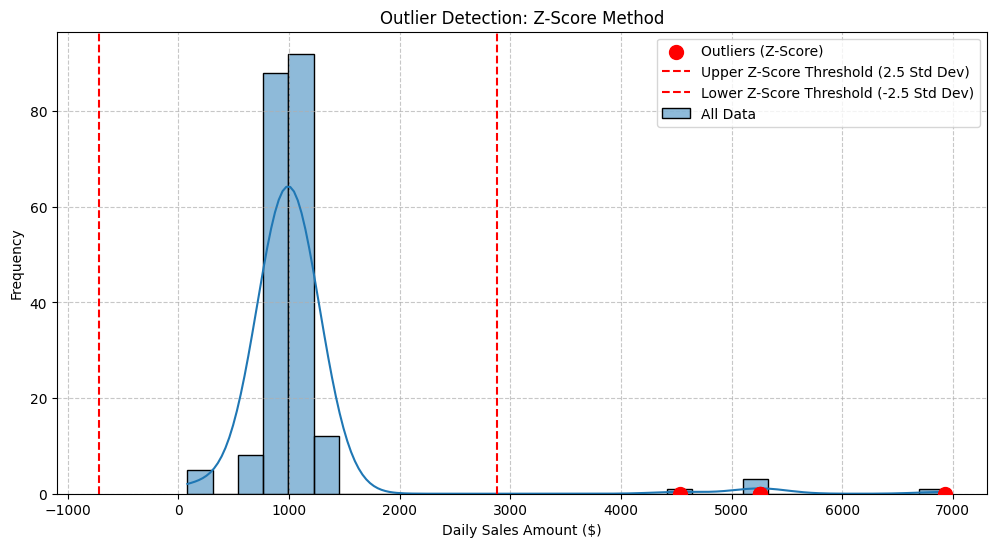

In [ ]:
# 2. Z-Score Method
from scipy.stats import zscore

df['z_score'] = np.abs(zscore(df['daily_sales_amount']))

z_score_threshold = 2.5 # A common threshold, can be adjusted based on domain knowledge
outliers_z_score = df[df['z_score'] > z_score_threshold]

print(f"--- Outliers detected by Z-Score (threshold > {z_score_threshold}) ---\n")
display(outliers_z_score)

# Visualize Z-score outliers on a histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_sales_amount'], kde=True, bins=30, label='All Data')
plt.scatter(outliers_z_score['daily_sales_amount'], np.zeros(len(outliers_z_score)), color='red', s=100, label='Outliers (Z-Score)', zorder=5)
plt.axvline(x=df['daily_sales_amount'].mean() + z_score_threshold * df['daily_sales_amount'].std(), color='red', linestyle='--', label=f'Upper Z-Score Threshold ({z_score_threshold} Std Dev)')
plt.axvline(x=df['daily_sales_amount'].mean() - z_score_threshold * df['daily_sales_amount'].std(), color='red', linestyle='--', label=f'Lower Z-Score Threshold ({-z_score_threshold} Std Dev)')
plt.title('Outlier Detection: Z-Score Method')
plt.xlabel('Daily Sales Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Outlier Detection using IQR Method**

The Interquartile Range (IQR) method is robust to skewed data and defines outliers as data points that fall below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$.

--- Outliers detected by IQR (Lower Bound: 599.61, Upper Bound: 1369.21) ---



,daily_sales_amount,z_score
113,1369.486317,0.403433
179,1408.025375,0.457177
200,167.889368,1.272239
201,178.039226,1.258084
202,204.152562,1.221668
203,202.690103,1.223708
204,81.116532,1.393247
205,4531.087480,4.812403
206,5257.517634,5.825436
207,5256.892975,5.824565


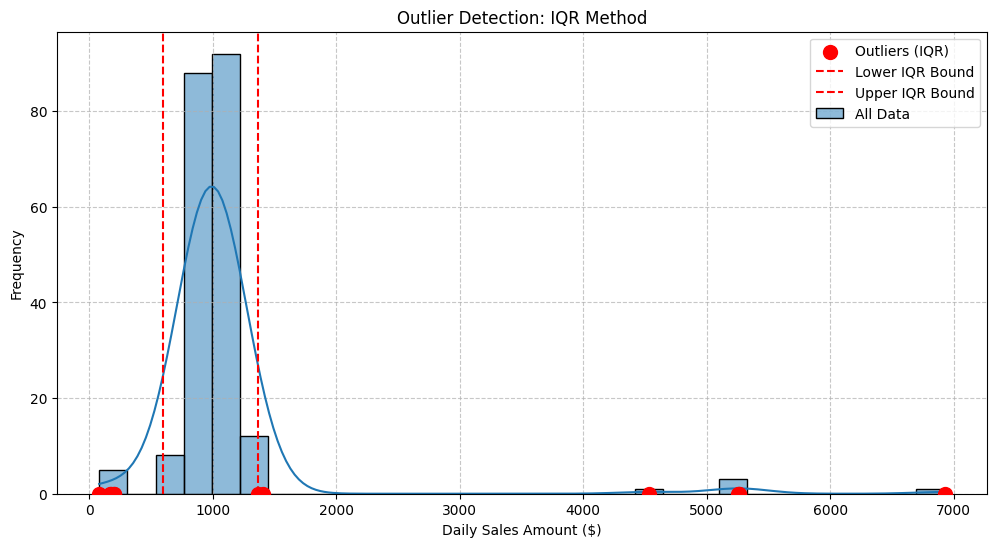

In [ ]:
# 3. IQR Method
Q1 = df['daily_sales_amount'].quantile(0.25)
Q3 = df['daily_sales_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['daily_sales_amount'] < lower_bound) | (df['daily_sales_amount'] > upper_bound)]

print(f"--- Outliers detected by IQR (Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}) ---\n")
display(outliers_iqr)

# Visualize IQR outliers on a histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['daily_sales_amount'], kde=True, bins=30, label='All Data')
plt.scatter(outliers_iqr['daily_sales_amount'], np.zeros(len(outliers_iqr)), color='red', s=100, label='Outliers (IQR)', zorder=5)
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Lower IQR Bound')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Upper IQR Bound')
plt.title('Outlier Detection: IQR Method')
plt.xlabel('Daily Sales Amount ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<br><br>

- ### **Treatment:**

### **Outlier Treatment: Removal**

One straightforward approach is to remove the identified outliers from the dataset. This can be suitable when outliers are likely due to errors or when their extreme values disproportionately influence analysis and model training, and their removal does not lead to significant data loss or bias.

--- Original DataFrame Shape ---
(210, 1)

--- DataFrame Shape after Outlier Removal (IQR) ---
(198, 1)


,daily_sales_amount
count,198.000000
mean,989.895754
std,134.527099
min,607.038234
25%,893.308474
50%,996.999167
75%,1072.046881
max,1328.568344


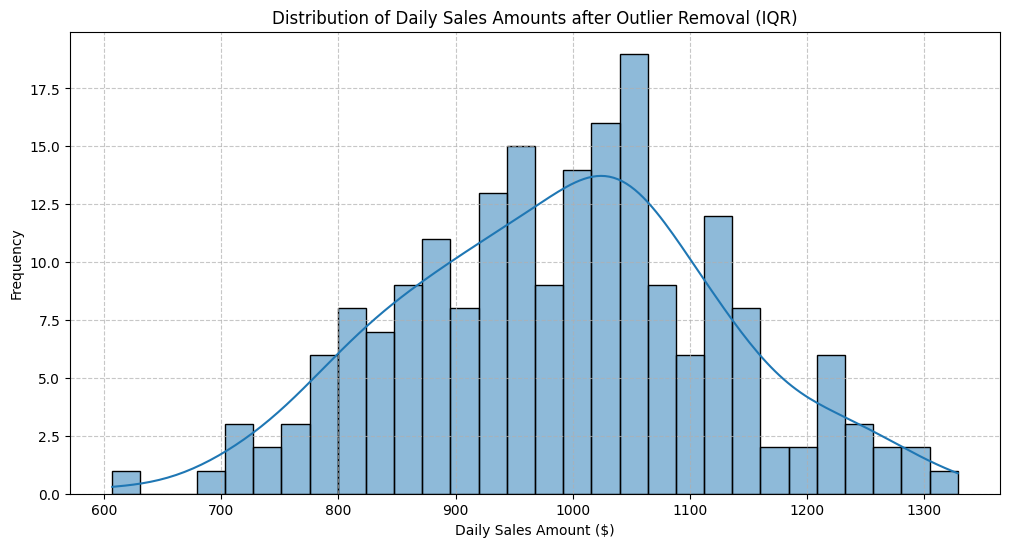

In [ ]:
# Treatment 1: Removal of Outliers (using IQR method for demonstration)
df_cleaned_removed = df[~((df['daily_sales_amount'] < lower_bound) | (df['daily_sales_amount'] > upper_bound))].copy()

print("--- Original DataFrame Shape ---")
print(df.shape)
print("\n--- DataFrame Shape after Outlier Removal (IQR) ---")
print(df_cleaned_removed.shape)

display(df_cleaned_removed.describe())

# Visualize the distribution after removal
plt.figure(figsize=(12, 6))
sns.histplot(df_cleaned_removed['daily_sales_amount'], kde=True, bins=30)
plt.title('Distribution of Daily Sales Amounts after Outlier Removal (IQR)')
plt.xlabel('Daily Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Outlier Treatment: Log Transformation**

Log transformation (or other power transformations like square root) can be used to reduce the skewness of the data and compress the range of extreme values. This is particularly useful for highly skewed distributions where large values have a disproportionate impact. It makes the data more amenable to models that assume normality or linearity.

--- Original Daily Sales Amount Description ---


,daily_sales_amount
count,210.000000
mean,1080.191174
std,718.797334
min,81.116532
25%,888.210524
50%,999.371217
75%,1080.610814
max,6926.365745



--- Log-Transformed Daily Sales Amount Description ---


,daily_sales_amount_log
count,210.000000
mean,6.889815
std,0.413453
min,4.408139
25%,6.790331
50%,6.908125
75%,6.986206
max,8.843235


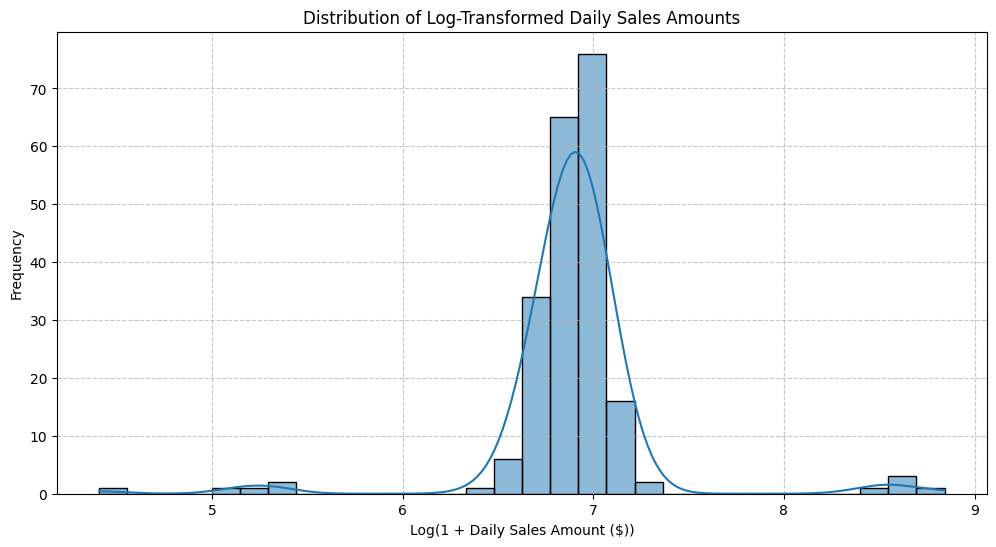

In [ ]:
# Treatment 2: Log Transformation
# Apply log transformation to the 'daily_sales_amount' column
# Add a small constant to handle zero or negative values if they exist, though not an issue with this synthetic data.
df_transformed = df.copy()
df_transformed['daily_sales_amount_log'] = np.log1p(df_transformed['daily_sales_amount']) # np.log1p(x) computes log(1+x)

print("--- Original Daily Sales Amount Description ---")
display(df['daily_sales_amount'].describe())
print("\n--- Log-Transformed Daily Sales Amount Description ---")
display(df_transformed['daily_sales_amount_log'].describe())

# Visualize the distribution after log transformation
plt.figure(figsize=(12, 6))
sns.histplot(df_transformed['daily_sales_amount_log'], kde=True, bins=30)
plt.title('Distribution of Log-Transformed Daily Sales Amounts')
plt.xlabel('Log(1 + Daily Sales Amount ($))')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Trimming or Fixing Based Off Domain Knowledge**

Sometimes, outliers aren't just statistical anomalies; they might represent data errors or unique, non-recurring events that a business wants to exclude or adjust based on specific domain understanding. This approach involves leveraging subject matter expertise to define what constitutes an "acceptable" range for data points and then actively removing or correcting values outside that range. This differs from statistical methods (like Z-score or IQR) in that the thresholds are often qualitative or based on business rules rather than purely on data distribution.

--- Domain Knowledge Treatment: 1 sales below $100 were adjusted to $100 ---

--- Original Daily Sales Amount Description ---


,daily_sales_amount
count,210.000000
mean,1080.191174
std,718.797334
min,81.116532
25%,888.210524
50%,999.371217
75%,1080.610814
max,6926.365745



--- Domain-Fixed Daily Sales Amount Description ---


,daily_sales_amount_fixed
count,210.000000
mean,1080.281095
std,718.672923
min,100.000000
25%,888.210524
50%,999.371217
75%,1080.610814
max,6926.365745


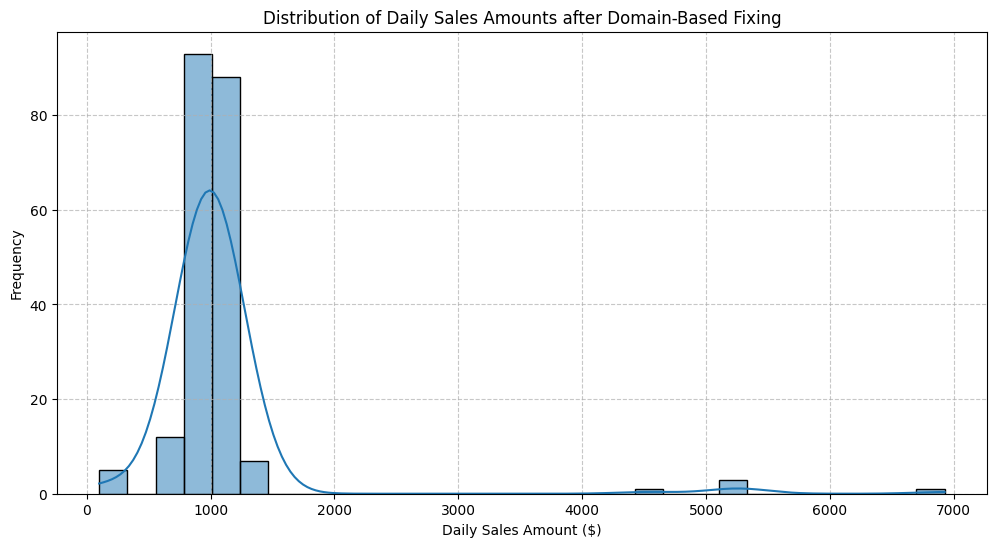

In [ ]:
# Treatment 4: Trimming/Fixing Based Off Domain Knowledge
# Let's assume, based on domain knowledge, that any daily sales amount below $100 is considered an erroneous entry (e.g., system glitch, test transaction).
# We will replace these values with a plausible minimum sales amount, say $100.

df_domain_treated = df.copy()

# Define the domain-specific threshold
domain_lower_threshold = 100

# Identify 'erroneous' low sales
erroneous_low_sales_count = df_domain_treated[df_domain_treated['daily_sales_amount'] < domain_lower_threshold].shape[0]

# Fix these 'erroneous' low sales by setting them to the minimum plausible value
df_domain_treated['daily_sales_amount_fixed'] = df_domain_treated['daily_sales_amount'].apply(lambda x: domain_lower_threshold if x < domain_lower_threshold else x)

print(f"--- Domain Knowledge Treatment: {erroneous_low_sales_count} sales below ${domain_lower_threshold} were adjusted to ${domain_lower_threshold} ---")

print("\n--- Original Daily Sales Amount Description ---")
display(df['daily_sales_amount'].describe())
print("\n--- Domain-Fixed Daily Sales Amount Description ---")
display(df_domain_treated['daily_sales_amount_fixed'].describe())

# Visualize the distribution after domain-based fixing
plt.figure(figsize=(12, 6))
sns.histplot(df_domain_treated['daily_sales_amount_fixed'], kde=True, bins=30)
plt.title('Distribution of Daily Sales Amounts after Domain-Based Fixing')
plt.xlabel('Daily Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()